In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

from evoscape import order_colors
from evoscape.landscapes import Landscape
from evoscape.modules import Node, UnstableNode, Center, NegCenter
import evoscape.landscape_visuals as vis
import evoscape.morphogen_regimes as mr
%load_ext autoreload

In [2]:
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 200})
plt.rcParams.update({'font.size': 15})  
plt.rcParams['axes.grid'] = False

import cmcrameri.cm as cm


In [3]:
order_colors = (
    'gold',
    'tab:green',
    'tab:blue',
)

In [186]:
%autoreload
def phase_plots(
    land,
    xx,
    yy,
    t,
    n_grid=25,
    manifold_step_size=0.02,
    manifold_steps=1000,
    basin_dt=0.04,
    basin_steps=800,
    fp_tol=2e-2,
    vel_tol=2e-3,
    cycle_window=256,
):
    x_range = (float(np.min(xx)), float(np.max(xx)))
    y_range = (float(np.min(yy)), float(np.max(yy)))

    x_range = (-4., 4.)
    y_range = (-4., 4.)
    fixed_points = land.find_fixed_points(t, x_range, y_range, n_grid=n_grid)
    saddle_manifolds = land.find_saddle_manifolds(
        t,
        fixed_points=fixed_points,
        x_range=x_range,
        y_range=y_range,
        step_size=manifold_step_size,
        n_steps=manifold_steps,
        termination_tol=fp_tol,
        velocity_tol=vel_tol,
    )
    basin_result = land.find_attractor_basins_manifold(
        t,
        xx,
        yy,
        fixed_points=fixed_points,
        saddle_manifolds=saddle_manifolds,
        dt=basin_dt,
        n_steps=basin_steps,
        fp_tol=fp_tol,
        vel_tol=vel_tol,
        cycle_window=cycle_window,
    )

    # print(basin_result)

    _, basin_ax, _ = vis.plot_attractor_basins_t(
        land,
        xx,
        yy,
        t,
        basin_result=basin_result,
        fixed_points=fixed_points,
        saddle_manifolds=saddle_manifolds,
        show_saddle_manifolds=True,
        nullclines=False,
        basin_coloring='module',
        module_order_colors=order_colors,
    )

    _, skeleton_ax, _ = vis.plot_phase_skeleton_t(
        land,
        xx,
        yy,
        t,
        basin_result=basin_result,
        fixed_points=fixed_points,
        saddle_manifolds=saddle_manifolds,
        show_saddle_manifolds=True,
        basin_coloring='module',
        module_order_colors=order_colors,
    )

    return basin_result



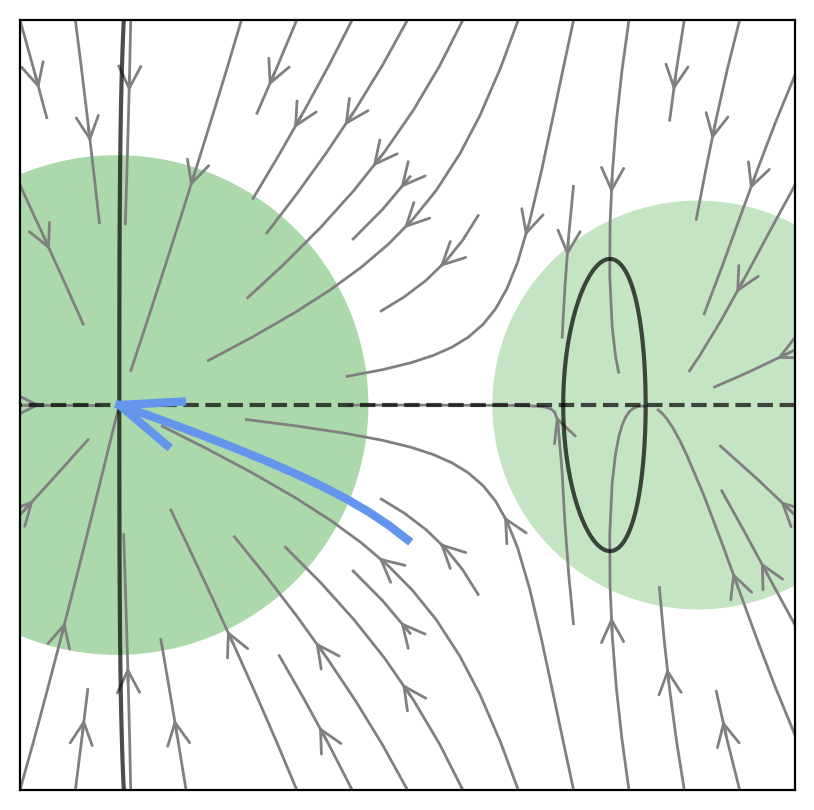

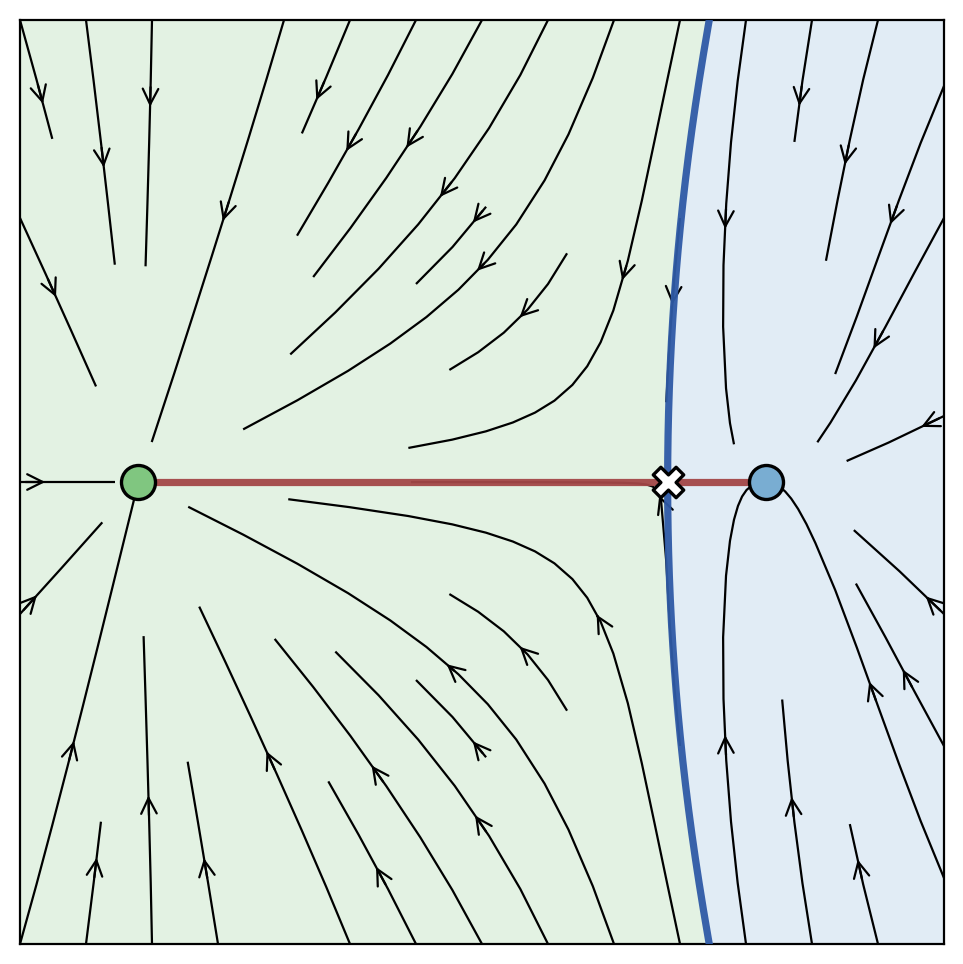

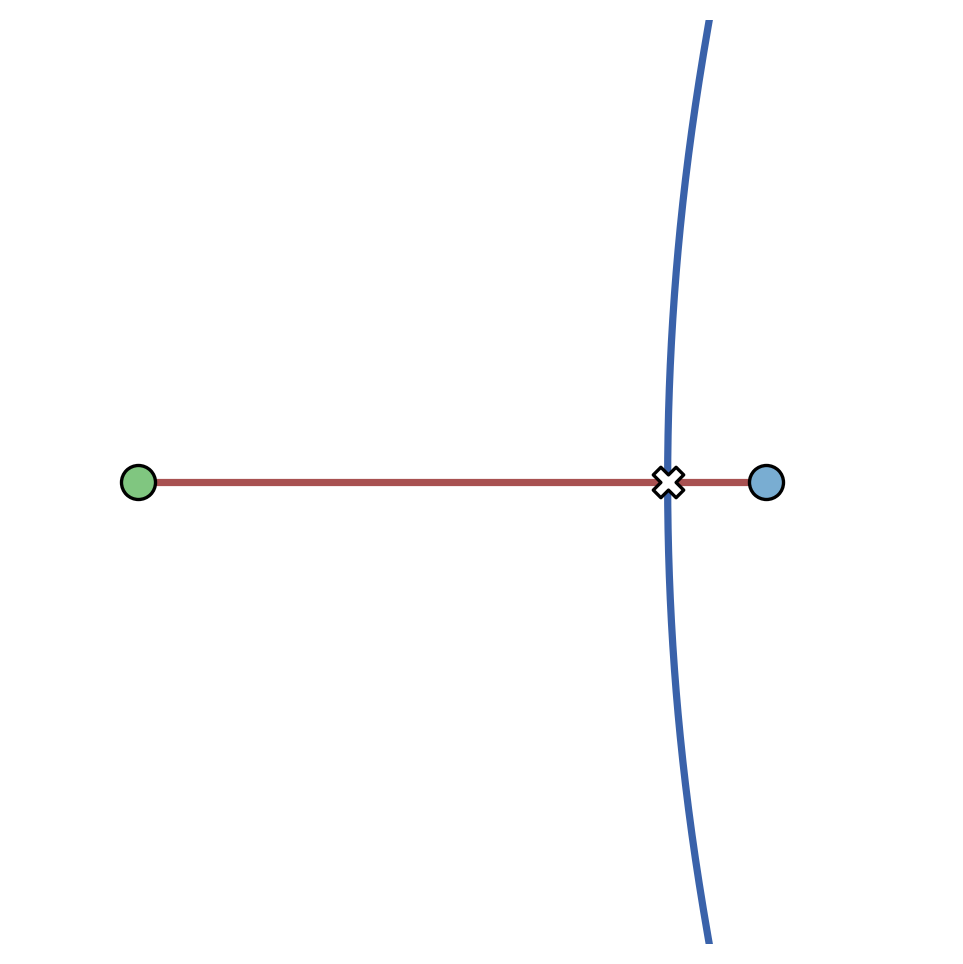

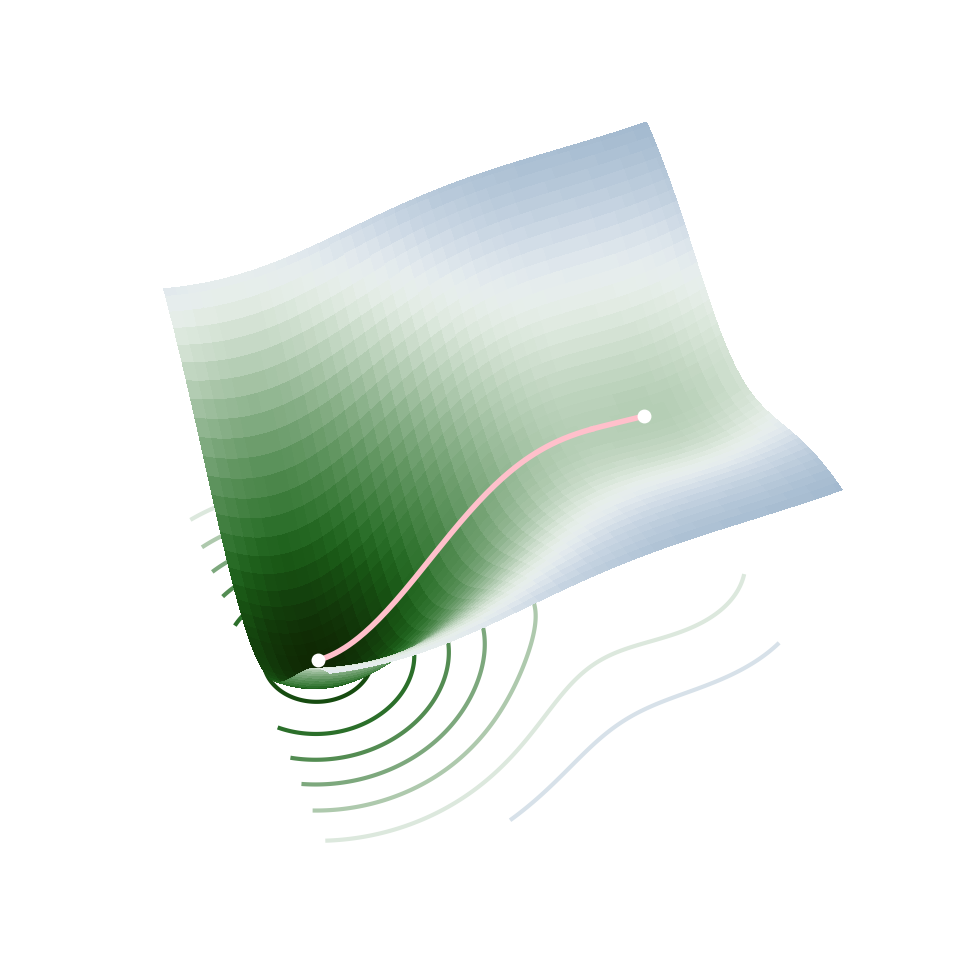

In [192]:
%autoreload
L = 2.
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

d = 1.5
l = 0.
M1 = Node(x=10., y=10., a=0., s=0.1)
M2 = Node(x=-d, y=-l, a=2.5, s=1.1)
M3 = Node(x=+d , y=-l, a=1.25, s=0.9)

traj_color = 'cornflowerblue'

landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types', traj_times=(0., 6., 61), traj_init_cond=(0., -0.7), traj_color=traj_color)

res = phase_plots(landscape, xx, yy, t=0.)
# print(res)

zlim=(-3., 0.5)
fig = vis.visualize_potential(landscape, xx, yy, 0, elev=50, azim=-110, color_scheme='fp_types', cmap_center=-0.6, axes=False, zlim=zlim, basin_result=res, show_saddle_manifolds=True)


Landscape with modules:
Node: x=-0.0; y=1.5; a=1.5; s=0.9,
Node: x=-1.1; y=-1.0; a=1.5; s=0.9,
Node: x=1.1; y=-1.0; a=1.5; s=0.9


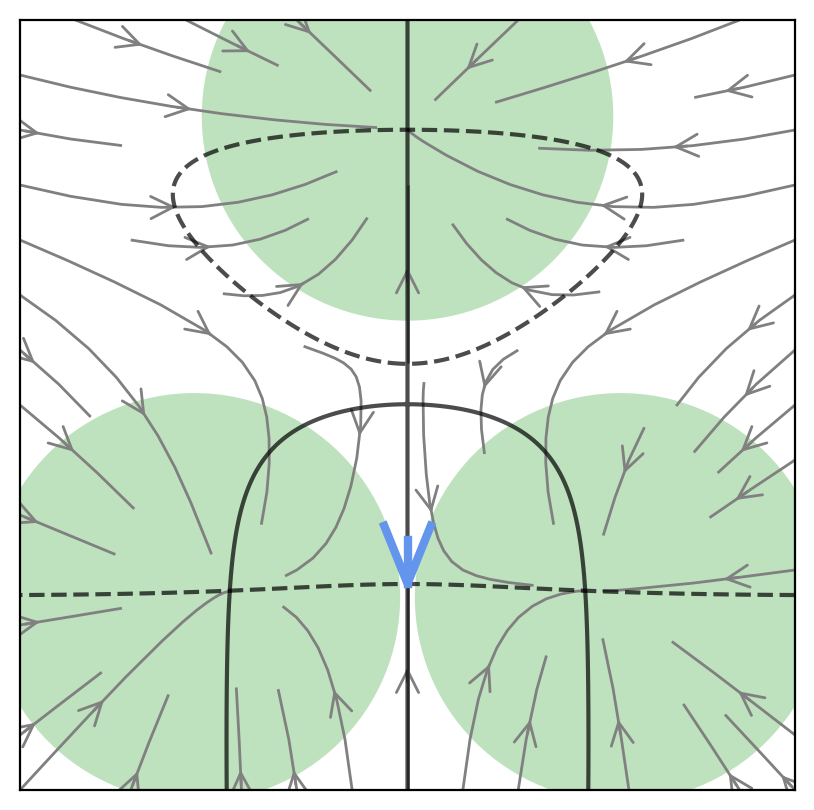

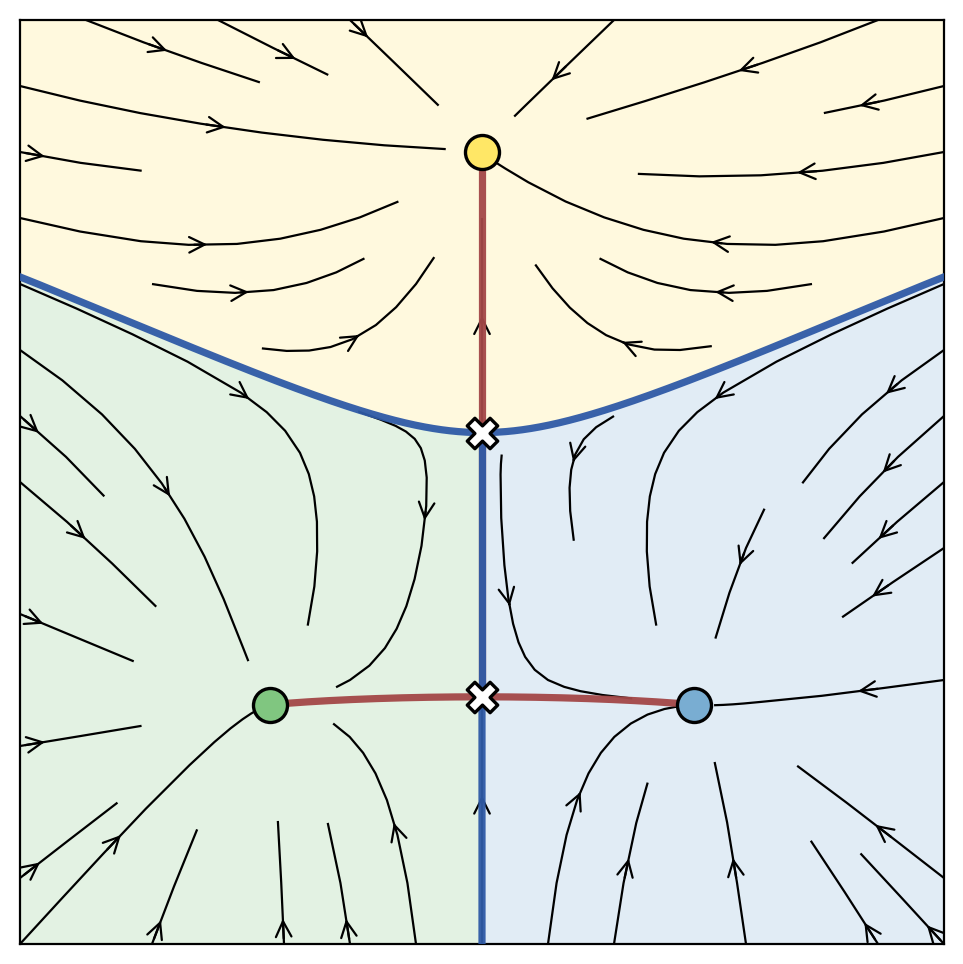

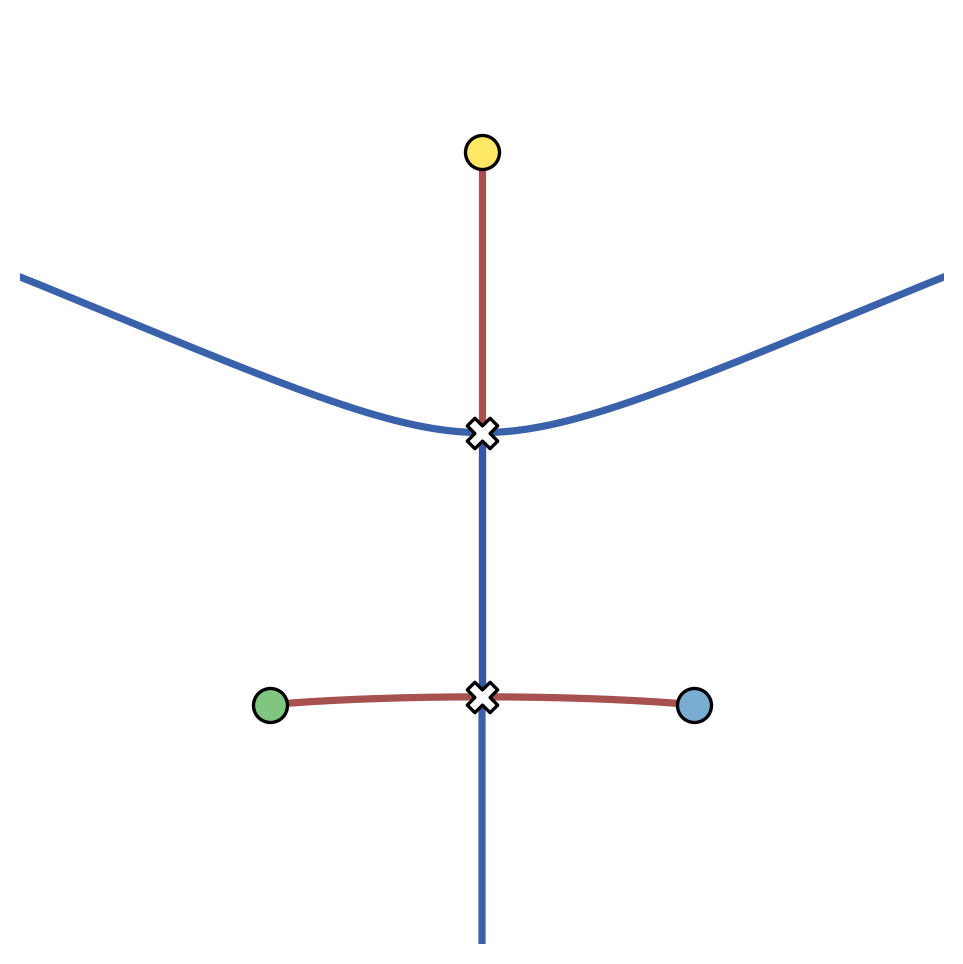

In [138]:
%autoreload
L = 2.
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

d = 1.1
l = 1.
M1 = Node(x=-0., y=1.5, a=1.5, s=0.9)
M2 = Node(x=-d, y=-l, a=1.5, s=0.9)
M3 = Node(x=+d , y=-l, a=1.5, s=0.9)

traj_color = 'cornflowerblue'

landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types', traj_times=(0., 6., 61), traj_init_cond=(0., -0.7), traj_color=traj_color)
print(landscape)
res = phase_plots(landscape, xx, yy, t=0.)


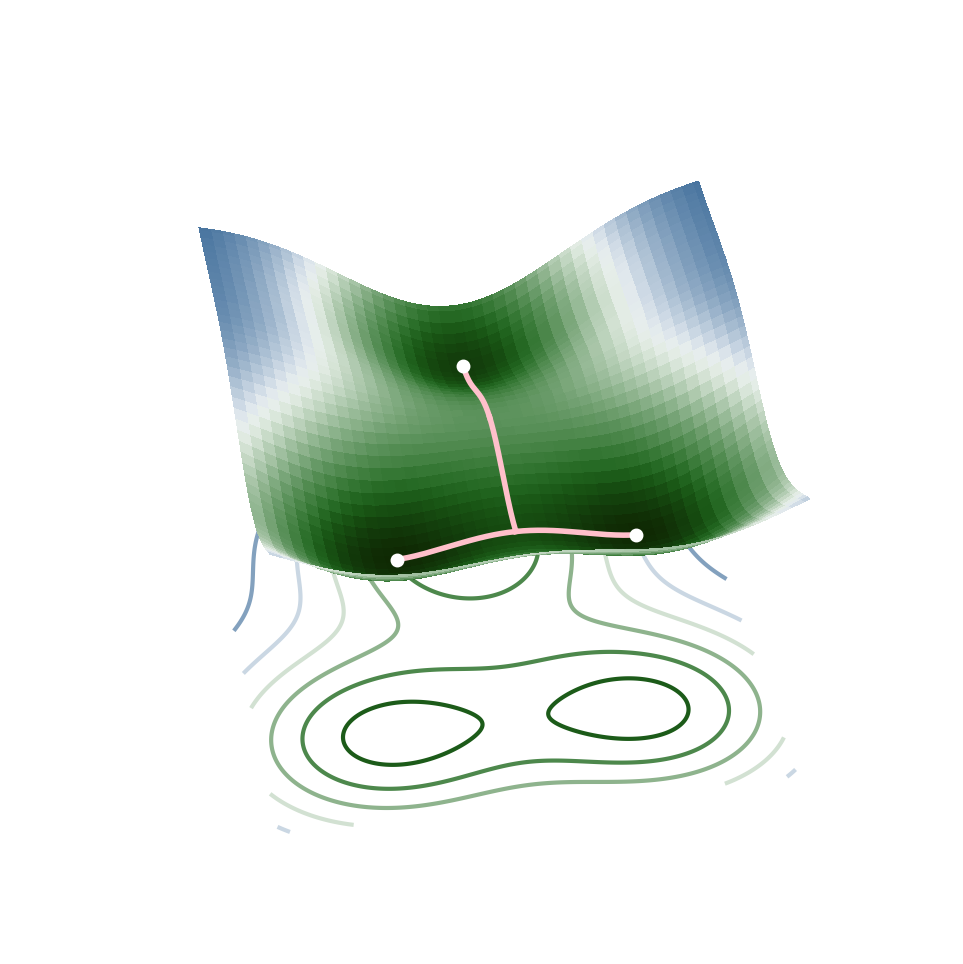

In [139]:
%autoreload
zlim=(-3,0.5)
fig = vis.visualize_potential(landscape, xx, yy, 0, elev=35, azim=-100, color_scheme='fp_types', cmap_center=-0.5, axes=False, zlim=zlim, basin_result=res)

# fig1, ax1 = plt.subplots(1,1, figsize=(6,6))
# derivs, pot, rot = landscape(0., (xx, yy), return_potentials=True)
# ax1.contour(xx, yy, pot, zorder=0, cmap=cm.cork.reversed(), alpha=1., linewidths=4)
# # ax1.streamplot(xx, yy, *derivs, density=0.2, arrowsize=2., arrowstyle='->', linewidth=3, color='grey', zorder=0, minlength=0.3)
# ax1.axis('off')
# plt.show()

Landscape with modules:
Node: x=-0.0; y=1.5; a=1.5; s=0.9,
Node: x=-1.1; y=-1.0; a=1.5; s=0.9,
Node: x=1.1; y=-1.0; a=1.5; s=0.95


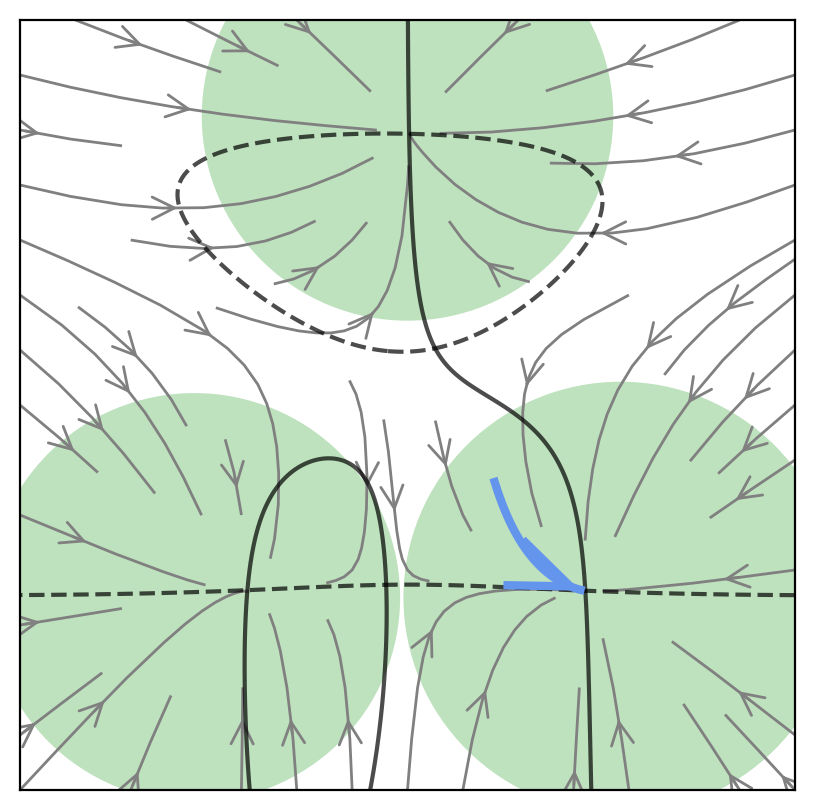

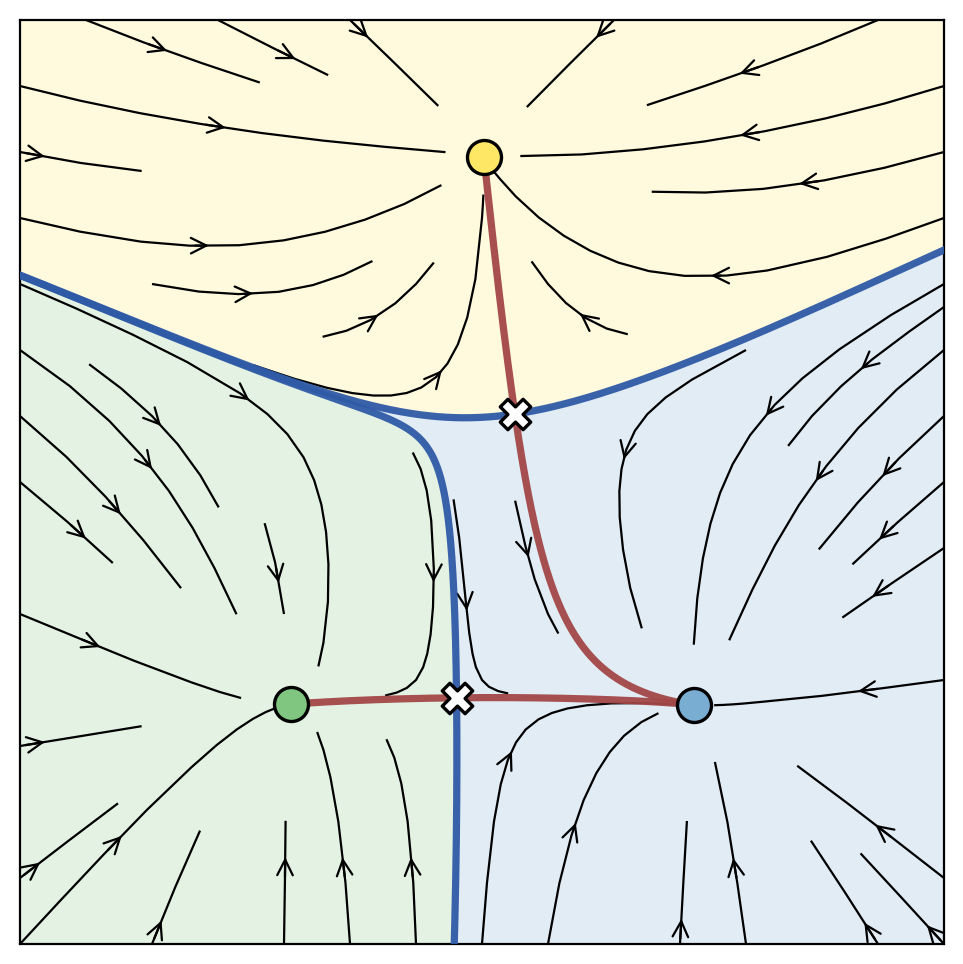

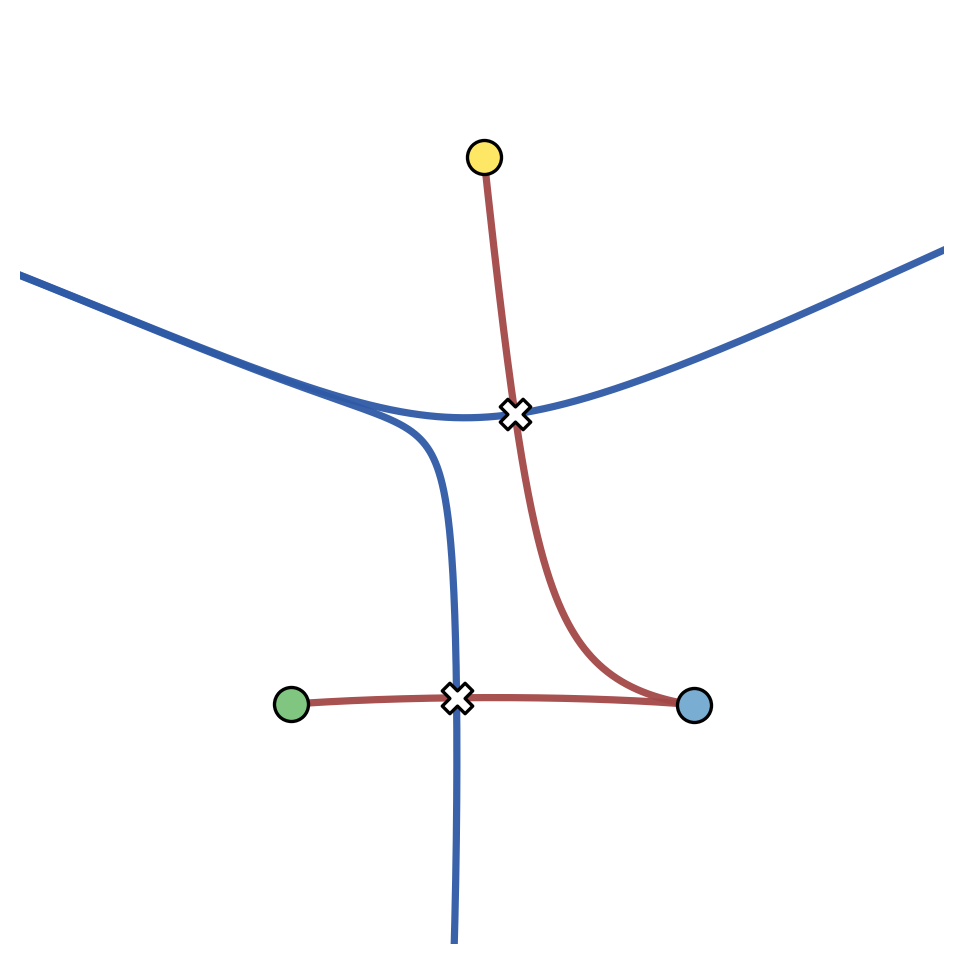

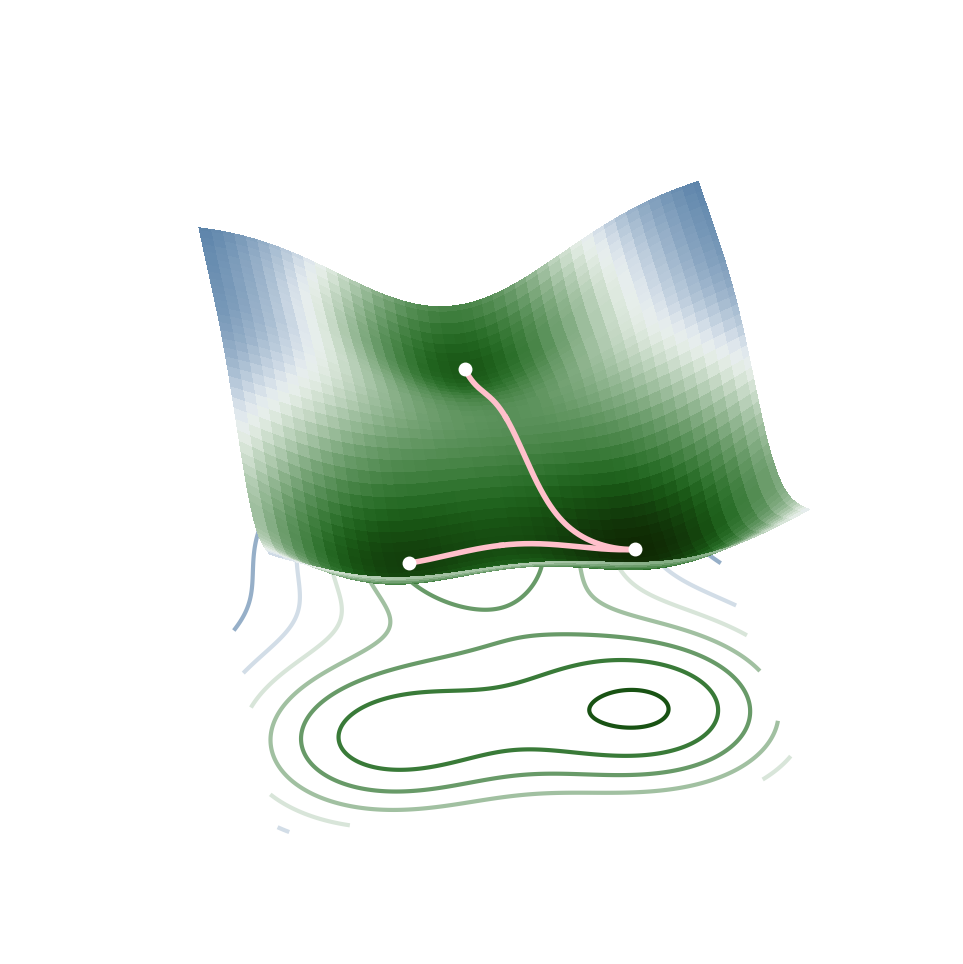

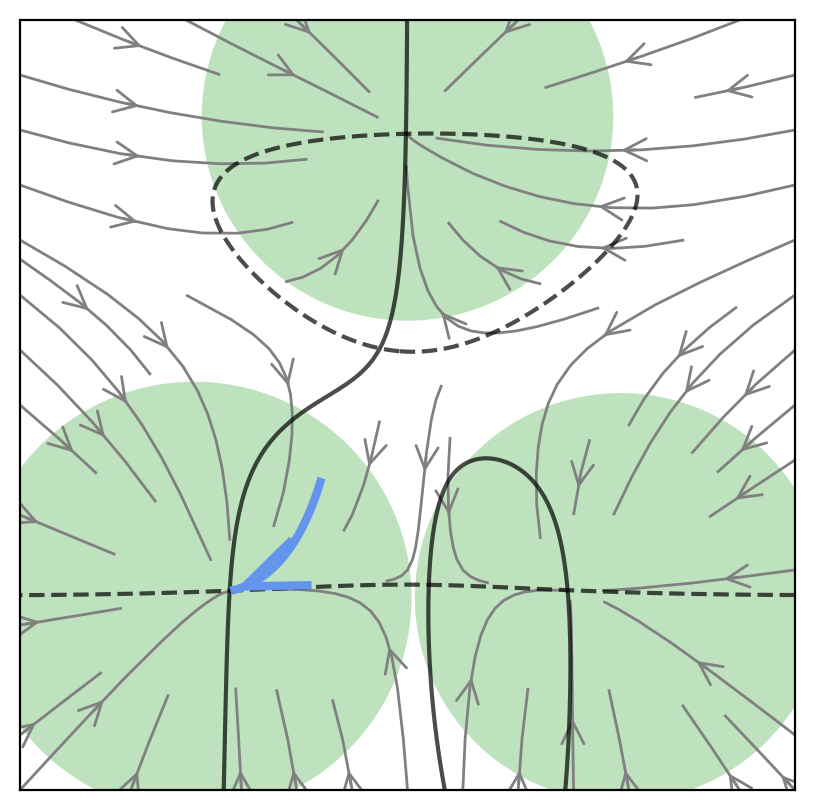

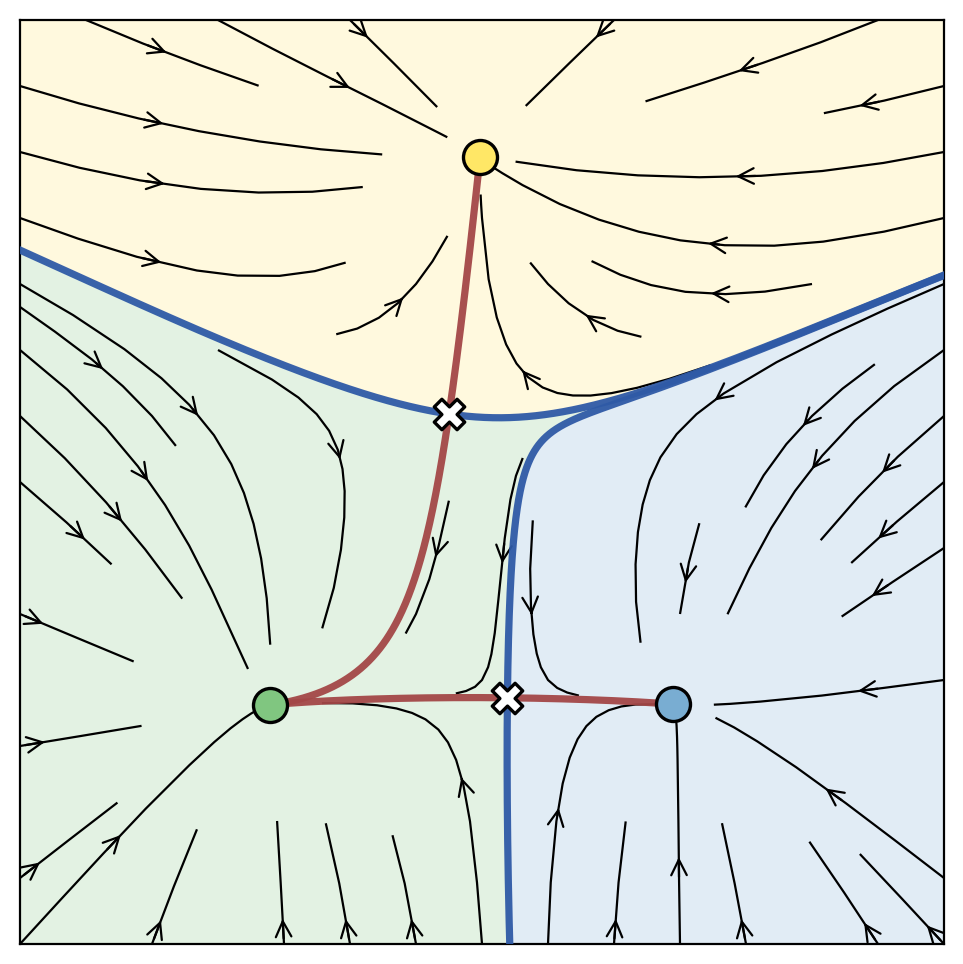

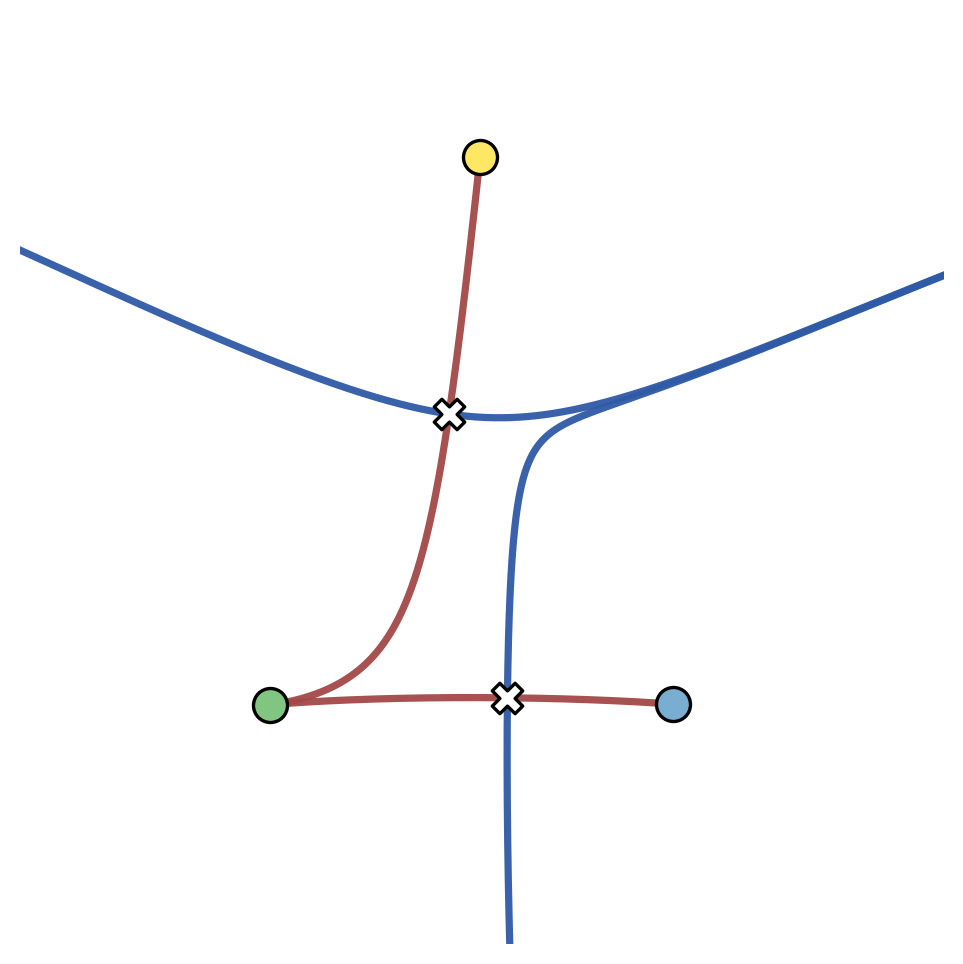

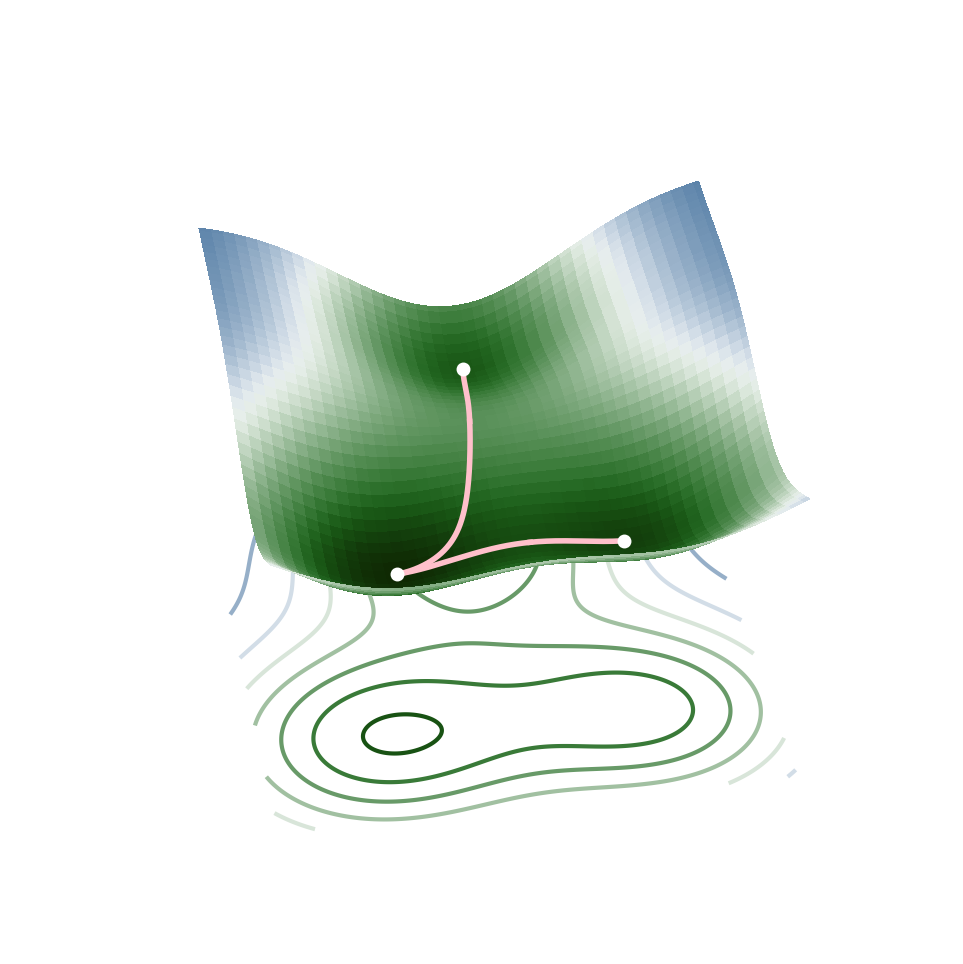

In [140]:

M3 = Node(x=+d , y=-l, a=1.5, s=0.95)
landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types', traj_times=(0., 4., 45), traj_init_cond=(0.45, -0.4), traj_color=traj_color)
print(landscape)

res = phase_plots(landscape, xx, yy, t=0.)
fig = vis.visualize_potential(landscape, xx, yy, 0, elev=35, azim=-100, color_scheme='fp_types', cmap_center=-0.5, axes=False, zlim=zlim, basin_result=res)

# fig = vis.visualize_potential(landscape, xx, yy, 0, elev=30, azim=-100, color_scheme='fp_types', cmap_center=0, axes=False, zlim=zlim)


M2 = Node(x=-d, y=-l, a=1.5, s=0.95)
M3 = Node(x=+d , y=-l, a=1.5, s=0.9)
landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types', traj_times=(0., 4., 45), traj_init_cond=(-0.45, -0.4), traj_color=traj_color)
res = phase_plots(landscape, xx, yy, t=0.)
fig = vis.visualize_potential(landscape, xx, yy, 0, elev=35, azim=-100, color_scheme='fp_types', cmap_center=-0.5, axes=False, zlim=zlim, basin_result=res)

# fig = visualize_potential(landscape, xx, yy, 0, elev=30, azim=-100, color_scheme='fp_types', cmap_center=0, axes=False, zlim=zlim)

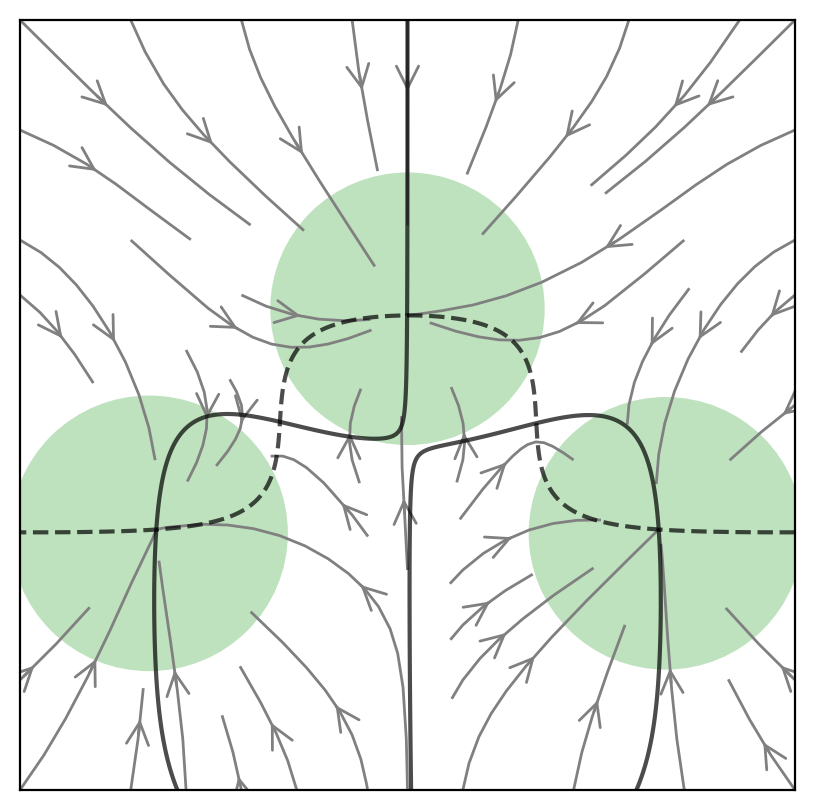

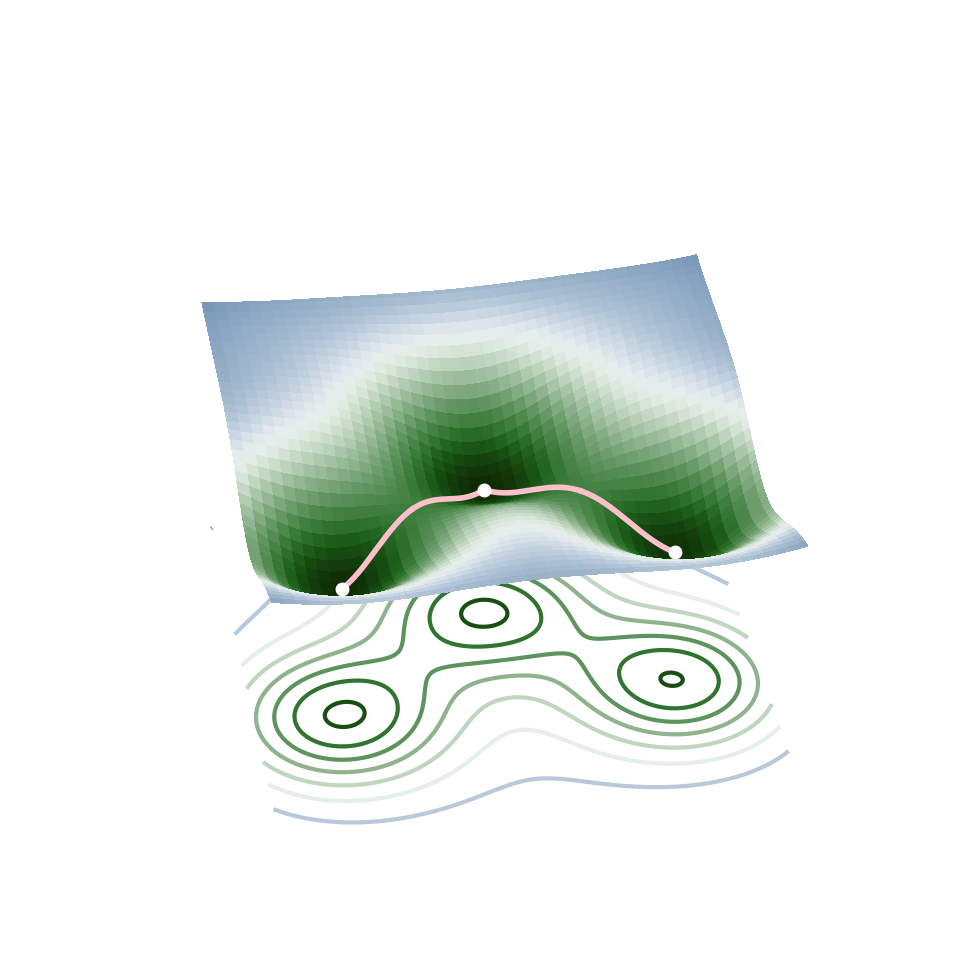

In [134]:
%autoreload
L = 3.
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

d = 2.
l = 1.
M1 = Node(x=-0., y=0.75, a=1.5, s=0.9)
M2 = Node(x=-d, y=-l, a=1.5, s=0.91)
M3 = Node(x=+d , y=-l, a=1.5, s=0.9)
zlim=(-3,2)
traj_color = 'cornflowerblue'

landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types',)
# res = phase_plots(landscape, xx, yy, t=0.)

fig = vis.visualize_potential(landscape, xx, yy, 0, elev=35, azim=-100, color_scheme='fp_types', cmap_center=-0.2, axes=False, zlim=zlim, basin_result=res)

In [ ]:


fig1, ax1 = plt.subplots(1,1, figsize=(6,6))
derivs, pot, rot = landscape(0., (xx, yy), return_potentials=True)
ax1.contour(xx, yy, pot, zorder=0, cmap=cm.cork.reversed(), alpha=1., linewidths=4, levels=8)
# ax1.streamplot(xx, yy, *derivs, density=0.2, arrowsize=2., arrowstyle='->', linewidth=3, color='grey', zorder=0, minlength=0.3)
ax1.axis('off')
plt.show()

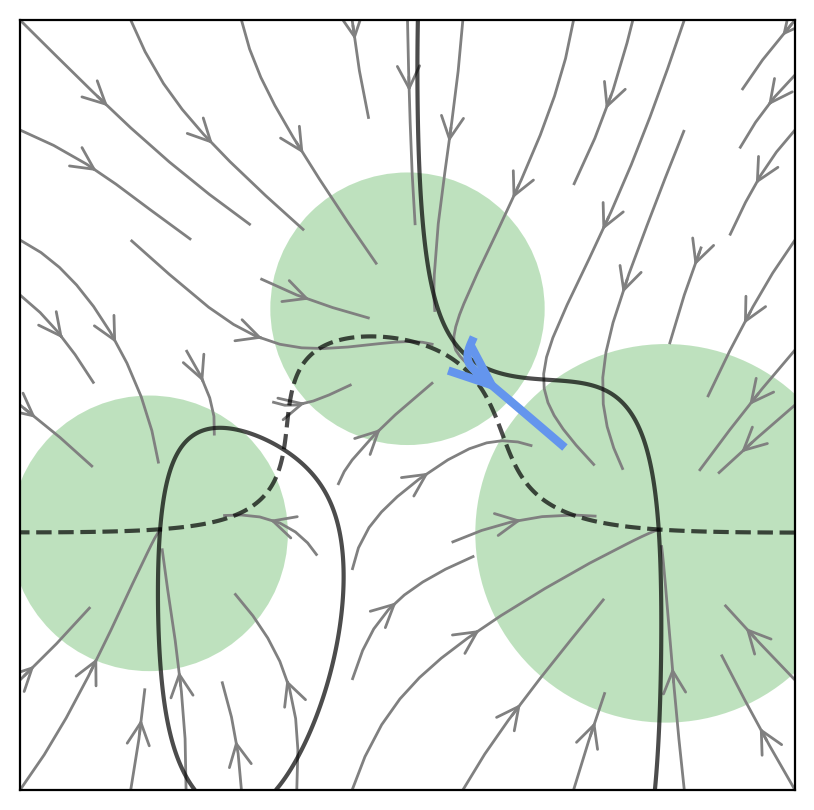

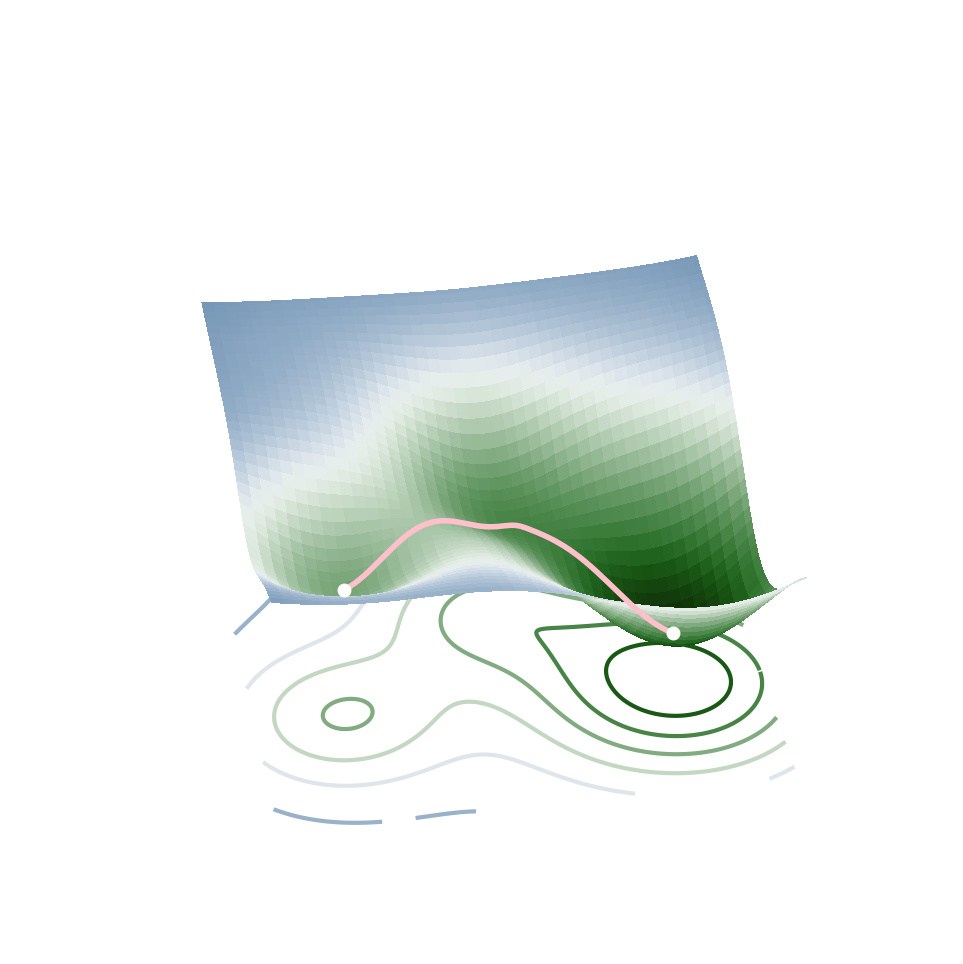

In [136]:

M3 = Node(x=+d , y=-l, a=1.5, s=1.25)
landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types', traj_times=(0., 6.5, 65), traj_init_cond=(0.5, 0.5), traj_color=traj_color)
# res = phase_plots(landscape, xx, yy, t=0.)

fig = vis.visualize_potential(landscape, xx, yy, 0, elev=35, azim=-100, color_scheme='fp_types', cmap_center=-0.5, axes=False, zlim=zlim, basin_result=res)

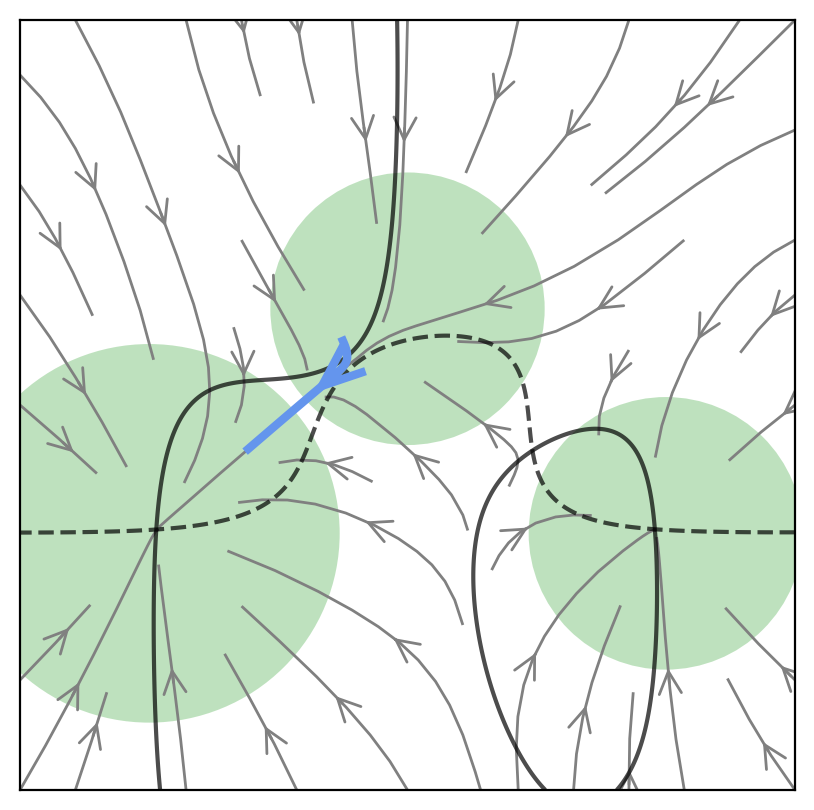

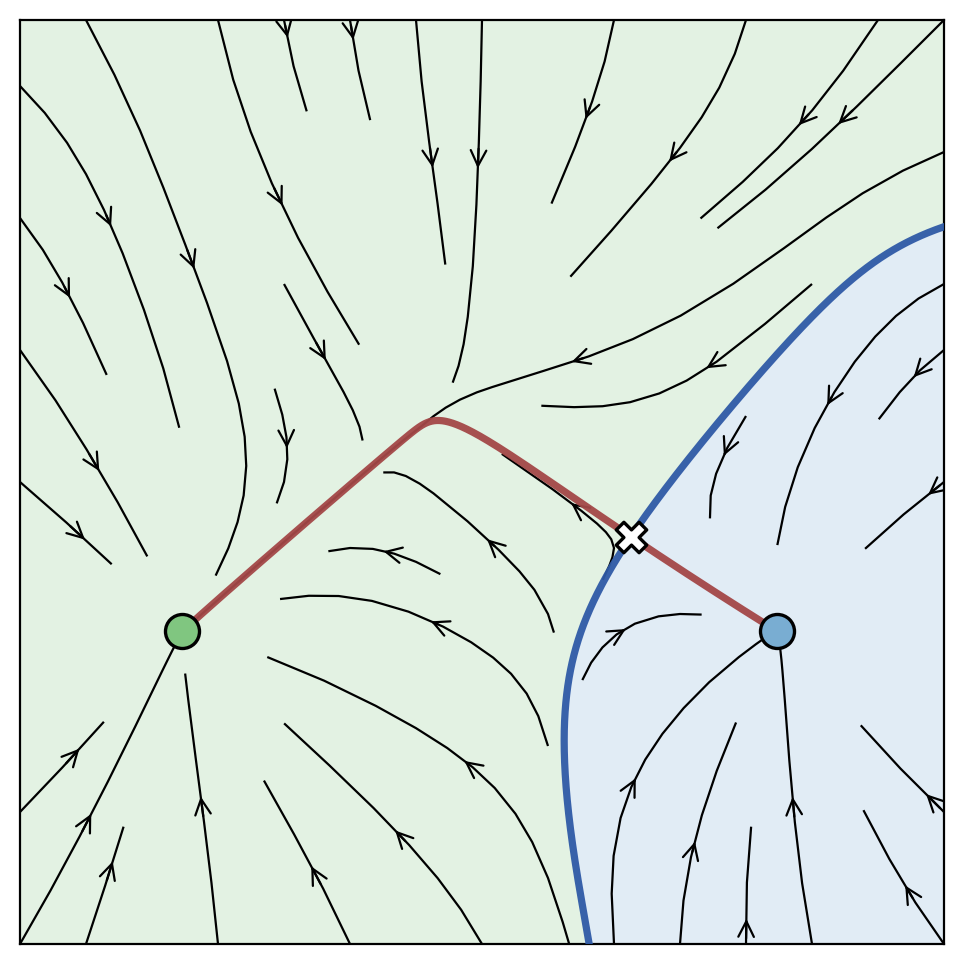

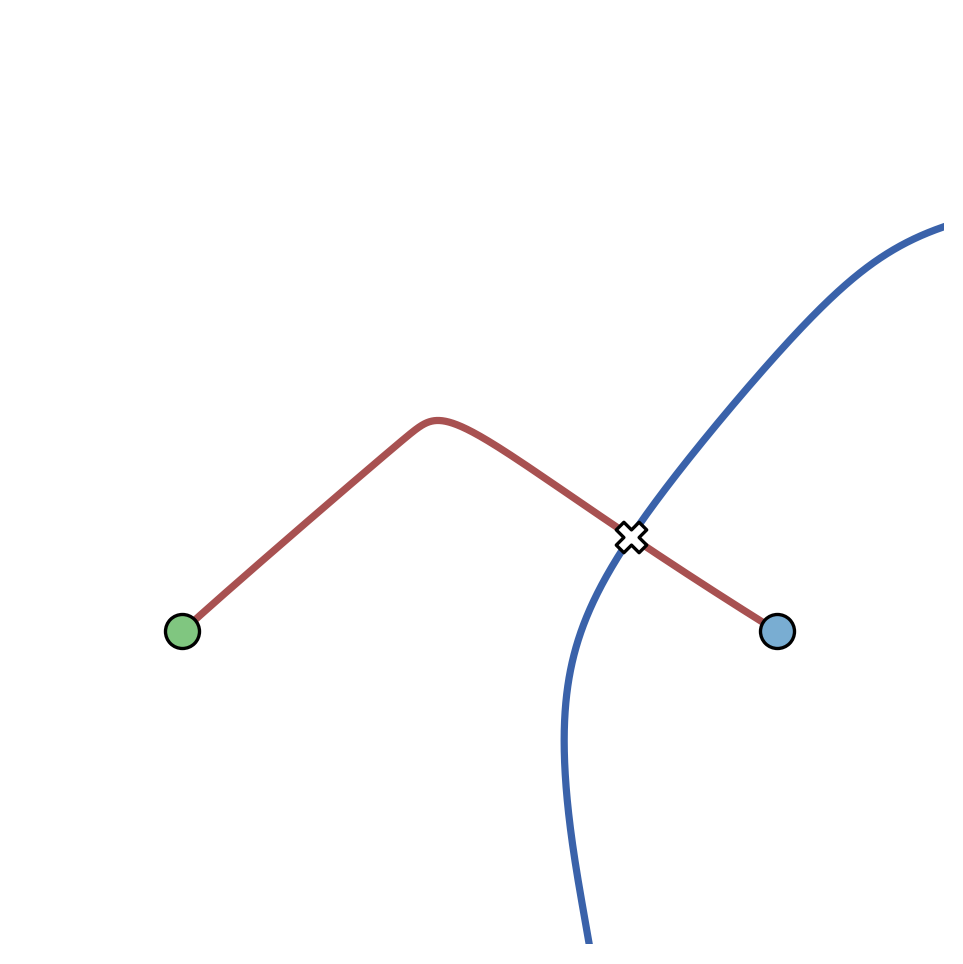

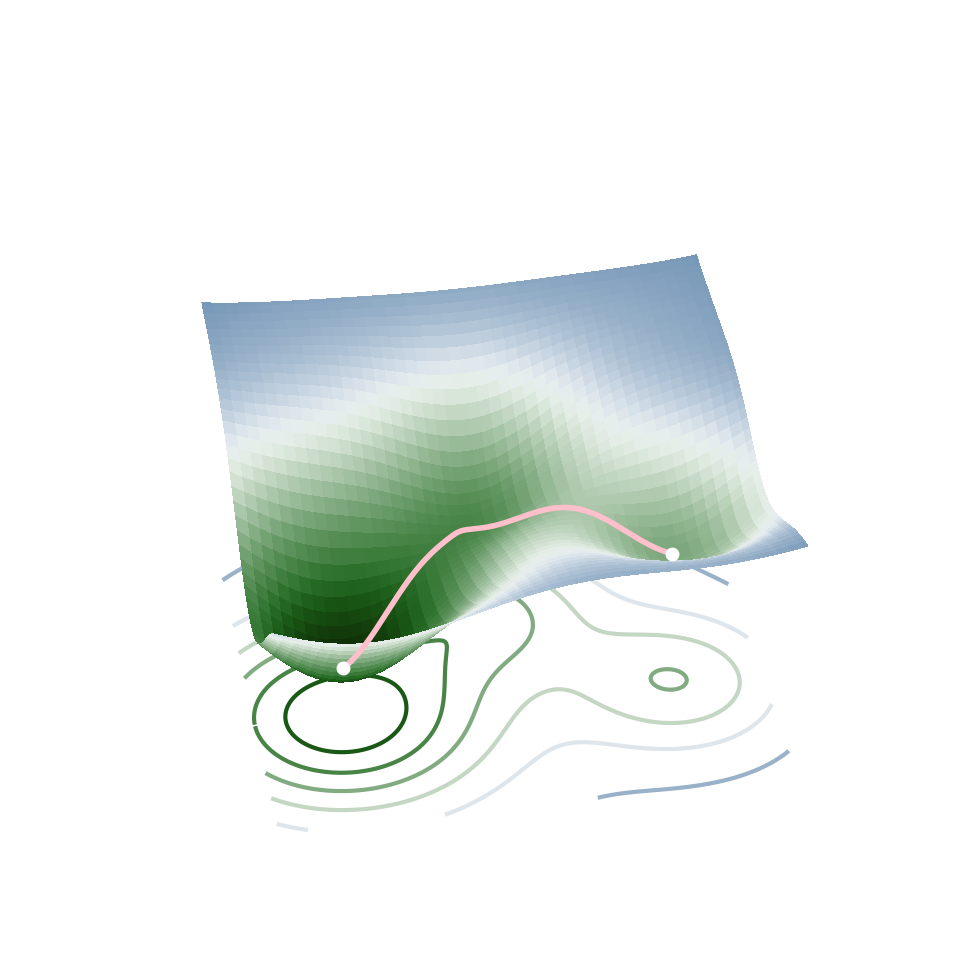

In [137]:


M2 = Node(x=-d, y=-l, a=1.5, s=1.25)
M3 = Node(x=+d , y=-l, a=1.5, s=0.9)
landscape = Landscape([M1, M2, M3], regime=mr.mr_const, A0=0.005)
fig, ax = vis.visualize_landscape_t(landscape, xx, yy, 0., color_scheme='fp_types', traj_times=(0., 6.5, 65), traj_init_cond=(-0.5, 0.5), traj_color=traj_color)
res = phase_plots(landscape, xx, yy, t=0.)


fig = vis.visualize_potential(landscape, xx, yy, 0, elev=35, azim=-100, color_scheme='fp_types', cmap_center=-0.5, axes=False, zlim=zlim, basin_result=res)


In [ ]:
Lx = 8.
Ly = 4.5
npoints = 401
qx = np.linspace(-Lx, Lx, npoints)
qy = np.linspace(-Ly, Ly, npoints)

xx, yy = np.meshgrid(qx,qy, indexing = 'xy')

par_limits = {
    'x': (-8.,8.),
    'y': (-8., 8.),
    'a': (0.5,3.),
    's': (0.5, 1.2),
}

par_choice_values = {}

used_fp_types = (Node,UnstableNode, Center, NegCenter)

start_module_list_1 = [Node.generate(
    par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(20)]
start_module_list_2 = [UnstableNode.generate(
    par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(5)]
# start_module_list_3 = [Center.generate(
#     par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(1)]
# start_module_list_4 = [NegCenter.generate(
#     par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(1)]

start_module_list = start_module_list_1 + start_module_list_2  #+ start_module_list_3 + start_module_list_4

landscape = Landscape(start_module_list, regime=mr.mr_piecewise, morphogen_times=(1.,), A0=0.0)


fig1, ax1 = plt.subplots(1,1, figsize=(16.5,9.5))
derivs, pot, rot = landscape(0., (xx, yy), return_potentials=True)
ax1.imshow(pot, extent=(-Lx,Lx,-Ly,Ly), origin='lower', cmap=cm.cork.reversed(), alpha=0.5, )
ax1.contour(xx, yy, pot, zorder=0, colors='w', alpha=1., linewidths=1, levels=15, linestyles='-')
ax1.axis('off')
plt.show()

In [ ]:
Lx = 48/6
Ly = 36/6
npoints = 401
qx = np.linspace(-Lx, Lx, npoints)
qy = np.linspace(-Ly, Ly, npoints)

xx, yy = np.meshgrid(qx,qy, indexing = 'xy')

par_limits = {
    'x': (-Lx,Lx),
    'y': (-Ly, Ly),
    'a': (0.5,3.),
    's': (0.5, 1.2),
}

par_choice_values = {}

used_fp_types = (Node,UnstableNode, Center, NegCenter)

start_module_list_1 = [Node.generate(
    par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(100)]
start_module_list_2 = [UnstableNode.generate(
    par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(50)]
# start_module_list_3 = [Center.generate(
#     par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(1)]
# start_module_list_4 = [NegCenter.generate(
#     par_limits,par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(1)]

start_module_list = start_module_list_1 + start_module_list_2  #+ start_module_list_3 + start_module_list_4

landscape = Landscape(start_module_list, regime=mr.mr_piecewise, morphogen_times=(1.,), A0=0.0)


fig1, ax1 = plt.subplots(1,1, figsize=(48,36))
plt.margins(0, 0)
derivs, pot, rot = landscape(0., (xx, yy), return_potentials=True)
ax1.imshow(pot, extent=(-Lx,Lx,-Ly,Ly), origin='lower', cmap=cm.cork.reversed(), alpha=0.5, )
ax1.contour(xx, yy, pot, zorder=0, colors='w', alpha=1., linewidths=1, levels=15, linestyles='-')
ax1.axis('off')
fig1.savefig('../poster_background_3.png', dpi=200,bbox_inches='tight')
plt.close(fig1)

In [ ]:
L = 4.
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

par_limits = {
    'x': (-3., 3.),
    'y': (-3., 3.),
    'a': (0.5, 5.),
    's': (0.5, 1.1),
}

par_choice_values = {}

start_module_list_1 = [Node.generate(
    par_limits, par_choice_values, immutable_pars_list=[], n_regimes=3) for i in range(4)]
start_module_list_2 = [UnstableNode.generate(
    par_limits, par_choice_values, immutable_pars_list=[], n_regimes=3) for i in range(2)]


start_module_list = start_module_list_1 #+ start_module_list_2 

landscape = Landscape(start_module_list, regime=mr.mr_piecewise, morphogen_times=(2., 7.), A0=0.005)

print(landscape)
fig = visualize_landscape(landscape, xx, yy, 0, color_scheme='fp_types')
fig = visualize_potential(landscape, xx, yy, 0, elev=30, azim=-100, color_scheme='order', cmap_center=0.2, scatter=True,)
ax = plt.gca()
ax.set_axis_off()


In [ ]:
L = 2.5
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

par_limits = {
    'x': (-2., 2.),
    'y': (-2., 2.),
    'a': (0.5, 5.),
    's': (0.5, 1.),
}

par_choice_values = {}

start_module_list_1 = [Node.generate(
    par_limits, par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(3)]

In [ ]:
start_module_list_2 = [Center.generate(
    par_limits, par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(1)]
start_module_list_3 = [NegCenter.generate(
    par_limits, par_choice_values, immutable_pars_list=[], n_regimes=2) for i in range(1)]


In [ ]:

start_module_list = start_module_list_1 + start_module_list_2 + start_module_list_3
for m in start_module_list:
    m.tau = 0.2
landscape = Landscape(start_module_list, regime=mr.mr_sigmoid, morphogen_times=(10.,), A0=0.005)
print(landscape)
fig = visualize_landscape(landscape, xx, yy, 0, color_scheme='fp_types')

derivs, pot, rot = landscape(0., (xx,yy), return_potentials=True)
fig, ax = plt.subplots(figsize=(6,6))
ax.streamplot(xx, yy, derivs[0], derivs[1], density=0.55, arrowsize=3., arrowstyle='->', linewidth=4.5,
                         color='darkseagreen', minlength=0.2)
ax.axis('off')

ncells = 3
nt = 15
init_cond = np.array(((-0.5, 0.5), (1.5, -2.), (2., 0.))).T
# init_cond = np.random.uniform(-2.,2., (2, ncells))
landscape.init_cells(ncells, init_cond)
traj, states = landscape.run_cells(0, 5, nt, 0.,)
fig, ax = plt.subplots(2, 1, figsize=(4,4), gridspec_kw={'height_ratios': [1, 0.2]})
for i in range(ncells):
    sc = ax[0].scatter(traj[0, i], traj[1, i], s=250, marker='o', c=np.arange(nt), alpha=0.5, cmap='viridis', edgecolors=None)
# ax[1].colorbar(sc)
fig.colorbar(sc, cax=ax[1], orientation='horizontal')
ax[0].set_xlim((-L*1.05, L*1.05))
ax[0].set_ylim((-L*1.05, L*1.05))
ax[0].axis('off')
ax[1].axis('off')


In [ ]:
start_module_list = start_module_list_1 + start_module_list_2 + start_module_list_3
landscape = Landscape(start_module_list, regime=mr.mr_piecewise, morphogen_times=(2.,), A0=0.005)
fig = visualize_landscape(landscape, xx, yy, 0, color_scheme='fp_types')

derivs, pot, rot = landscape(0., (xx,yy), return_potentials=True)
fig, ax = plt.subplots(figsize=(4,4))
ax.streamplot(xx, yy, derivs[0], derivs[1], density=0.55, arrowsize=3., arrowstyle='->', linewidth=3,
                         color='darkseagreen', minlength=0.2)
ax.axis('off')

ax_cbar = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])

    time_values = np.tile(np.arange(nt), (states.shape[0], 1))
    ax0.scatter(traj[0, :, :], traj[1, :, :], s=s, alpha=0.2, c=time_values, cmap=cmap_time, edgecolor=None)
    sc0 = ax0.scatter(2*L*np.ones(nt), 2*L*np.ones(nt), c=np.linspace(t0, tf, nt), cmap=cmap_time, alpha=0.7, s=0.01, edgecolors='none')
    tbar = fig.colorbar(sc0, cax=ax_cbar, orientation='horizontal', label='Time')
    if t_ticks is not None:
        tbar.set_ticks(np.linspace(*t_ticks))